In [1]:
import zipfile

with zipfile.ZipFile("Rising waters.zip.zip", "r") as zip_ref:
    zip_ref.extractall("project")

In [2]:
import os

os.listdir("project")

['Rising waters']

In [3]:
for root, dirs, files in os.walk("project"):
    print(root, files)

project []
project/Rising waters ['flood dataset.xlsx', 'flood prediction.ipynb']
project/Rising waters/.ipynb_checkpoints ['flood prediction-checkpoint.ipynb']


In [5]:
for root, dirs, files in os.walk("project"):
    print(root, files)

project []
project/Rising waters ['flood dataset.xlsx', 'flood prediction.ipynb']
project/Rising waters/.ipynb_checkpoints ['flood prediction-checkpoint.ipynb']


In [6]:
import zipfile

with zipfile.ZipFile("Rising waters.zip.zip", "r") as zip_ref:
    zip_ref.extractall("project")

print("Files extracted successfully!")

Files extracted successfully!


In [7]:
import os

for root, dirs, files in os.walk("project"):
    print(root)
    for file in files:
        print("  -", file)

project
project/Rising waters
  - flood dataset.xlsx
  - flood prediction.ipynb
project/Rising waters/.ipynb_checkpoints
  - flood prediction-checkpoint.ipynb


In [8]:
!pip install openpyxl

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
dataset = pd.read_excel("project/Rising waters/flood dataset.xlsx")
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [11]:
dataset.columns

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')

In [13]:
dataset.isnull().sum()

,0
Temp,0
Humidity,0
Cloud Cover,0
ANNUAL,0
Jan-Feb,0
Mar-May,0
Jun-Sep,0
Oct-Dec,0
avgjune,0
sub,0


In [14]:
dataset.isnull().sum()

,0
Temp,0
Humidity,0
Cloud Cover,0
ANNUAL,0
Jan-Feb,0
Mar-May,0
Jun-Sep,0
Oct-Dec,0
avgjune,0
sub,0


In [15]:
dataset.fillna(dataset.mean(numeric_only=True), inplace=True)

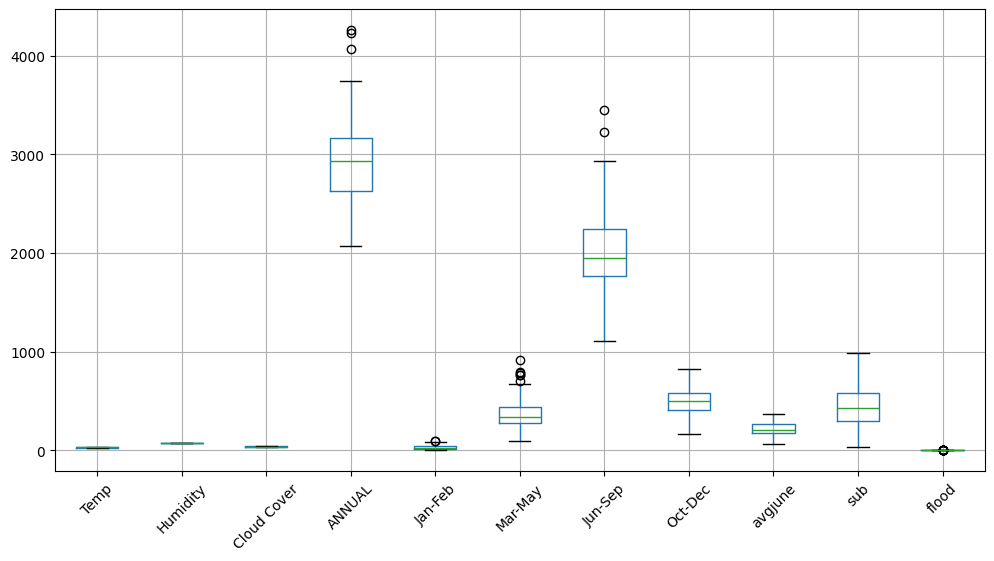

In [16]:
plt.figure(figsize=(12,6))
dataset.boxplot()
plt.xticks(rotation=45)
plt.show()

In [17]:
numeric_cols = dataset.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dataset[col] = dataset[col].clip(lower, upper)

print("Outliers handled successfully!")

Outliers handled successfully!


In [18]:
dataset.dtypes

,0
Temp,int64
Humidity,int64
Cloud Cover,int64
ANNUAL,float64
Jan-Feb,float64
Mar-May,float64
Jun-Sep,float64
Oct-Dec,float64
avgjune,float64
sub,float64


In [19]:
X = dataset.drop("flood", axis=1)
y = dataset["flood"]

print(X.shape)
print(y.shape)

(115, 10)
(115,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(86, 10)
(29, 10)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)

(86, 10)
(29, 10)


In [40]:
from sklearn import tree
from sklearn import ensemble
from sklearn import neighbors
import xgboost
from sklearn import metrics

In [41]:
dtree = tree.DecisionTreeClassifier()
Rf = ensemble.RandomForestClassifier()
knn = neighbors.KNeighborsClassifier()
xgb = xgboost.XGBClassifier()

In [44]:
dtree.fit(X_train, y_train)
Rf.fit(X_train, y_train)
knn.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [45]:
p1 = dtree.predict(X_test)
p2 = Rf.predict(X_test)
p3 = knn.predict(X_test)
p4 = xgb.predict(X_test)

In [46]:
from sklearn import metrics

print(metrics.accuracy_score(y_test, p1))
print(metrics.accuracy_score(y_test, p2))
print(metrics.accuracy_score(y_test, p3))
print(metrics.accuracy_score(y_test, p4))

1.0
1.0
1.0
1.0


In [48]:
from sklearn import metrics

print(metrics.confusion_matrix(y_test, p4))

[[29]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [49]:
print(metrics.accuracy_score(y_test, p4))

1.0


In [50]:
print(metrics.precision_score(y_test, p4))

0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
print(metrics.recall_score(y_test, p4))

0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
print(metrics.classification_report(y_test, p4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



In [53]:
import joblib

joblib.dump(xgb, "floods.save")

['floods.save']